# Análisis Covid-19

**Fuente:**

Ministerio de Ciencia, Tecnología, Conocimiento e Innovación (2023, 9 de noviembre), Datos del Repositorio COVID-19 [datos abiertos]. https://observa.minciencia.gob.cl/datos-abiertos/datos-del-repositorio-covid-19

Responder las siguientes preguntas siendo el termino "casos"igual a "casos confirmados":

1 día de mayor cantidad de casos

2 promedio de casos diarios

3 mediana de casos diarios

4 valor de la moda de casos


In [7]:
# si no están instaladas, use: install.packages("dplyr") y install.packages("lubridate")
library(dplyr)
library(lubridate)

In [9]:
# 1. Carga de los datos
# Se asume que el archivo se encuentra en el directorio de trabajo
data <- read.csv("../data/covid-19-region.csv", stringsAsFactors = FALSE)

# 2. Limpieza de datos
# Extraemos la columna y eliminamos los valores NA para evitar errores en los cálculos
casos_nuevos <- na.omit(data$Casosnuevostotales)

# 3. Cálculo de Medidas de Tendencia Central

# Media aritmética (promedio)
media_casos <- mean(casos_nuevos)

# Mediana (valor central)
mediana_casos <- median(casos_nuevos)

# Moda (valor con mayor frecuencia)
# Dado que R base no tiene una función de moda, definimos una personalizada
calcular_moda <- function(x) {
  valores_unicos <- unique(x)
  valores_unicos[which.max(tabulate(match(x, valores_unicos)))]
}
moda_casos <- calcular_moda(casos_nuevos)

# 4. Visualización de resultados
cat("--- Medidas de Tendencia Central: Casosnuevostotales ---\n")
cat("Media:   ", round(media_casos, 2), "\n")
cat("Mediana: ", mediana_casos, "\n")
cat("Moda:    ", moda_casos, "\n")

--- Medidas de Tendencia Central: Casosnuevostotales ---
Media:    187.16 
Mediana:  18 
Moda:     0 


Conteste las siguientes preguntas:
1. 

Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: lubridate

Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union

Loading required package: ggplot2
[1] "Total de nuevos casos por región:"
# A tibble: 16 × 2
   Region             Total_Nuevos_Casos
   <chr>                           <dbl>
 1 Metropolitana                  100162
 2 Valparaíso                       4369
 3 Tarapacá                         3081
 4 Antofagasta                      2673
 5 Biobío                           1886
 6 Maule                            1725
 7 Araucanía                        1126
 8 O’Higgins                        1086
 9 Coquimbo                          916
10 Ñuble                             743
11 Arica y Parinacota   

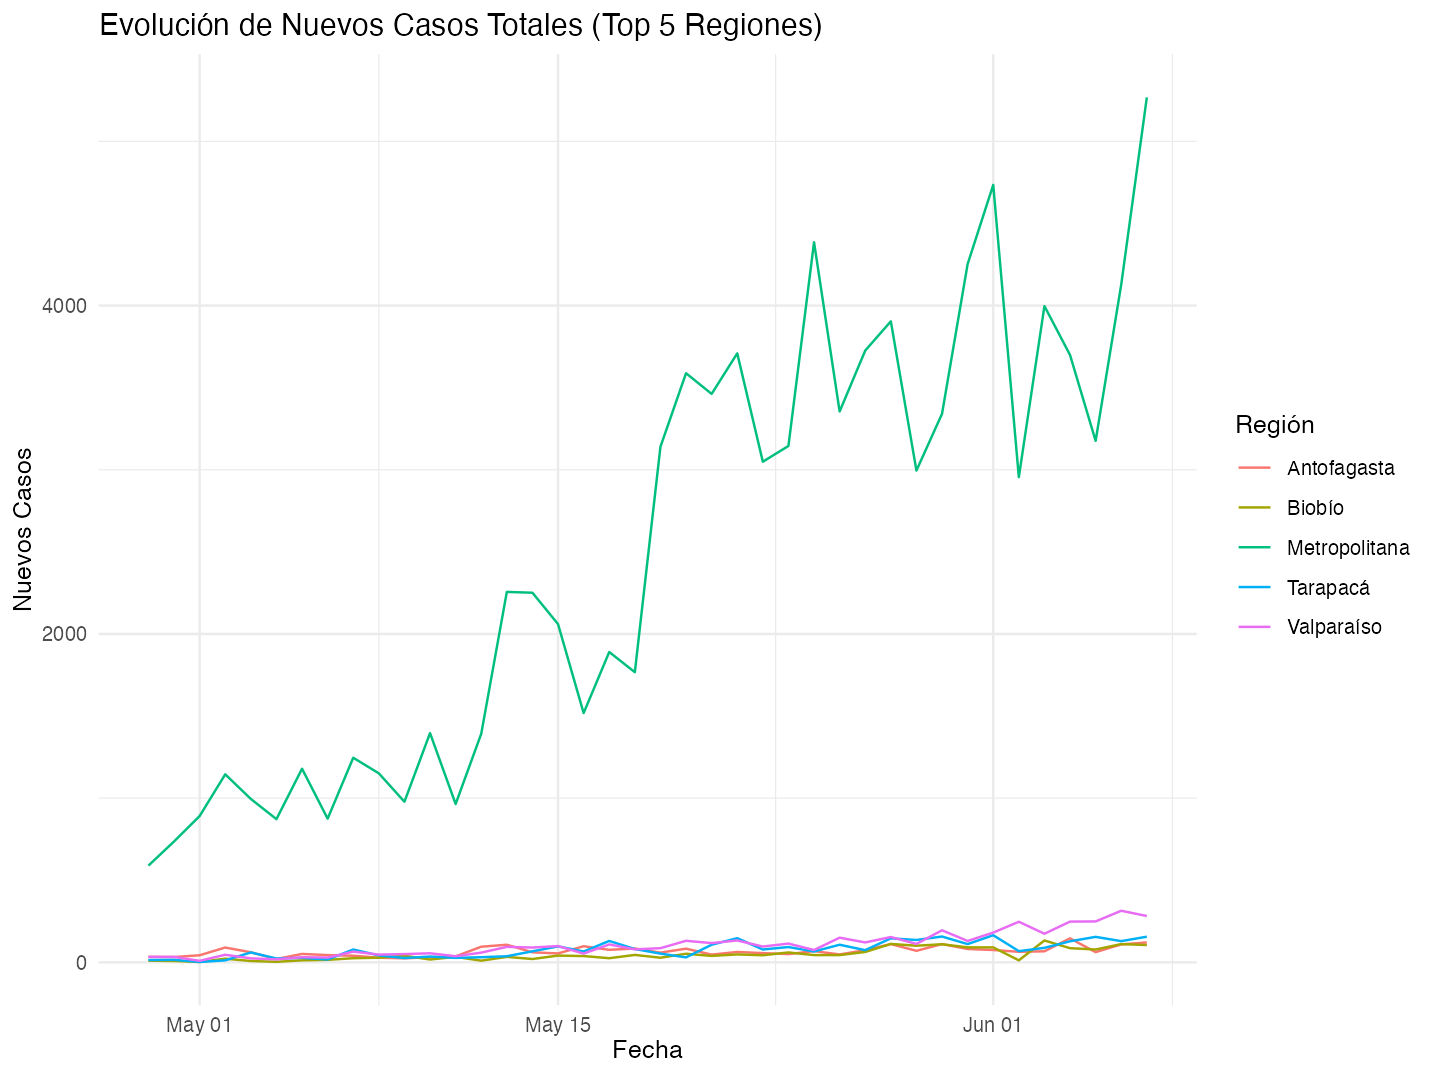

In [1]:
# 1. Cargar librerías necesarias
if (!require("dplyr")) install.packages("dplyr")
if (!require("lubridate")) install.packages("lubridate")
if (!require("ggplot2")) install.packages("ggplot2")

library(dplyr)
library(lubridate)
library(ggplot2)

# 2. Cargar el archivo
# Asegúrate de que el archivo 'covid-19-region.csv' esté en tu directorio de trabajo
df <- read.csv("../data/covid-19-region.csv", stringsAsFactors = FALSE, check.names = FALSE)

# 3. Limpieza y preparación de datos
df_clean <- df %>%
  # Convertir fecha al formato estándar de R (Año/Mes/Día)
  mutate(Fecha = ymd(Fecha)) %>%
  # Asegurar que la columna sea numérica (maneja posibles NA)
  mutate(Casosnuevostotales = as.numeric(Casosnuevostotales)) %>%
  # Filtrar filas donde la Región no sea el total nacional (si existe) y quitar NAs
  filter(!is.na(Casosnuevostotales), Region != "Total")

# --- RESPUESTAS A PREGUNTAS CLAVE ---

# Pregunta 1: ¿Cuál es el total de nuevos casos por región en todo el periodo?
resumen_region <- df_clean %>%
  group_by(Region) %>%
  summarise(Total_Nuevos_Casos = sum(Casosnuevostotales, na.rm = TRUE)) %>%
  arrange(desc(Total_Nuevos_Casos))

print("Total de nuevos casos por región:")
print(resumen_region)

# Pregunta 2: ¿Cuál fue el día con mayor cantidad de nuevos casos a nivel nacional?
max_dia_nacional <- df_clean %>%
  group_by(Fecha) %>%
  summarise(Suma_Diaria = sum(Casosnuevostotales, na.rm = TRUE)) %>%
  filter(Suma_Diaria == max(Suma_Diaria))

cat("\nEl día con más casos a nivel nacional fue:", as.character(max_dia_nacional$Fecha), 
    "con", max_dia_nacional$Suma_Diaria, "casos.\n")

# Pregunta 3: ¿Cuál es la región que tuvo el pico más alto de nuevos casos en un solo día?
pico_regional <- df_clean %>%
  filter(Casosnuevostotales == max(Casosnuevostotales, na.rm = TRUE)) %>%
  select(Region, Fecha, Casosnuevostotales)

print("\nPico máximo alcanzado por una región:")
print(pico_regional)

# 4. Visualización: Evolución de nuevos casos (Top 5 regiones)
top_5_regiones <- resumen_region$Region[1:5]

grafico_evolucion <- df_clean %>%
  filter(Region %in% top_5_regiones) %>%
  ggplot(aes(x = Fecha, y = Casosnuevostotales, color = Region)) +
  geom_line() +
  labs(title = "Evolución de Nuevos Casos Totales (Top 5 Regiones)",
       x = "Fecha",
       y = "Nuevos Casos",
       color = "Región") +
  theme_minimal()

# Mostrar gráfico
print(grafico_evolucion)

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


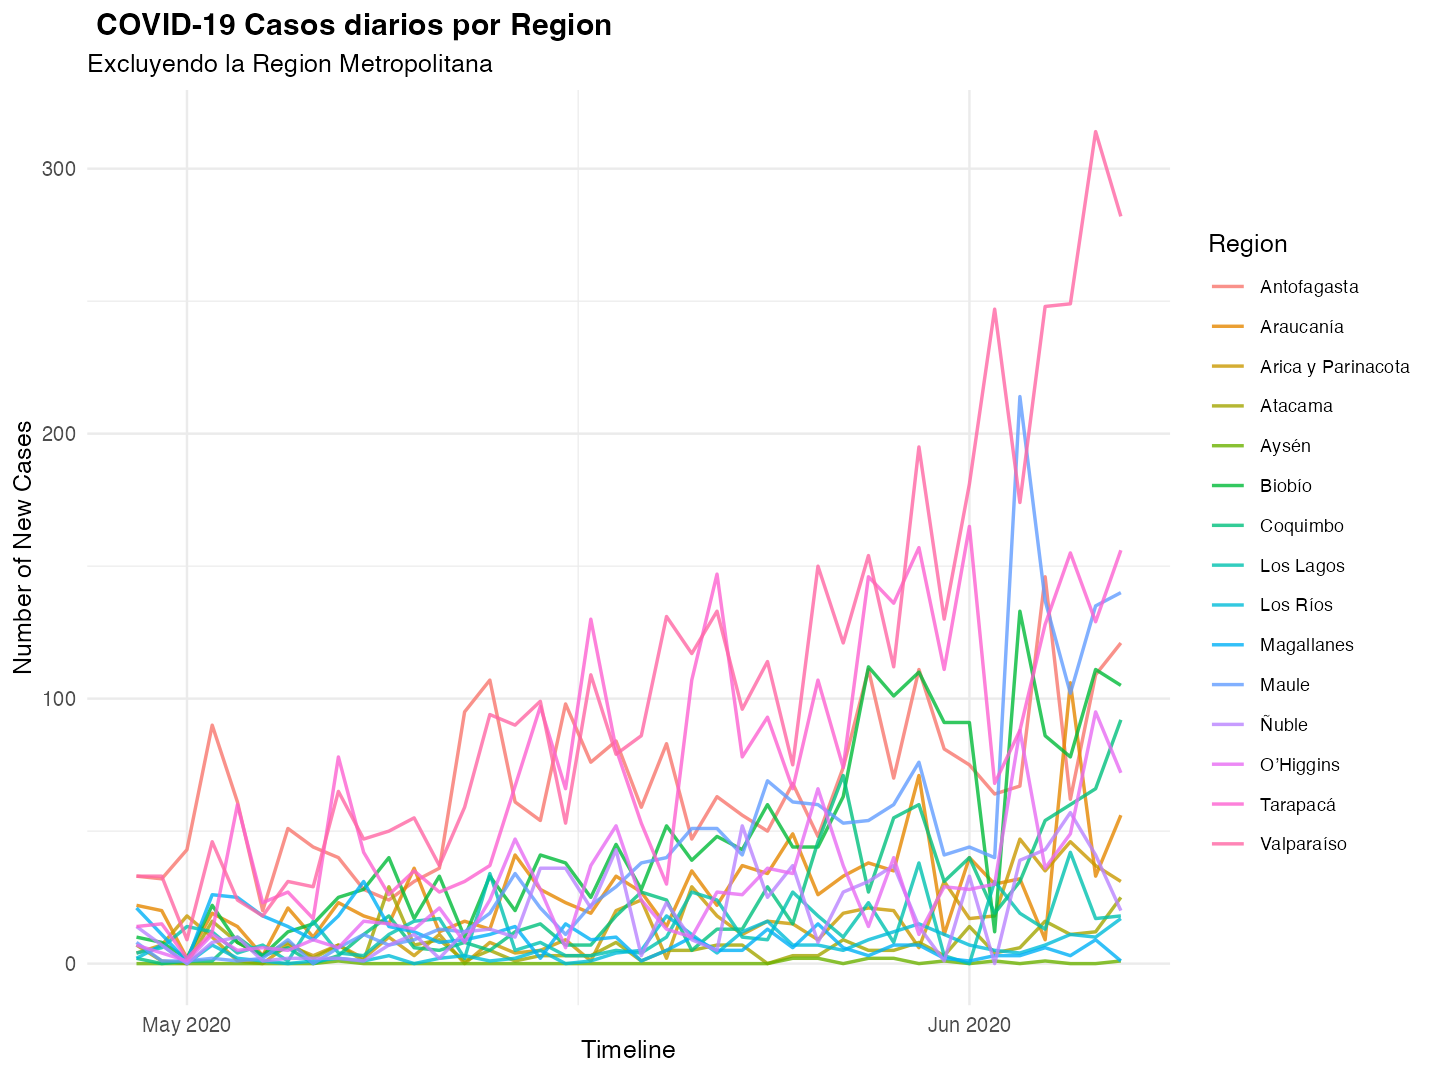

In [2]:
# Load required libraries
library(dplyr)
library(ggplot2)
library(lubridate)

# 1. Load the dataset
# df <- read.csv("../data/covid-19-region.csv", stringsAsFactors = FALSE, check.names = FALSE)

# 2. Preprocess and filter the data
# We convert the date and filter out both 'Metropolitana' and the national 'Total'
df_regional <- df_clean %>%
  mutate(Fecha = ymd(Fecha),
         Casos_Nuevos = as.numeric(Casosnuevostotales)) %>%
  filter(!is.na(Fecha), 
         !is.na(Casos_Nuevos),
         Region != "Metropolitana", 
         Region != "Total")

# 3. Create the multi-line time-series graph
ggplot(df_regional, aes(x = Fecha, y = Casos_Nuevos, color = Region)) +
  geom_line(alpha = 0.8, size = 0.7) +
  theme_minimal() +
  labs(title = " COVID-19 Casos diarios por Region",
       subtitle = "Excluyendo la Region Metropolitana",
       x = "Timeline",
       y = "Number of New Cases",
       color = "Region") +
  theme(legend.position = "right",
        legend.text = element_text(size = 8),
        plot.title = element_text(face = "bold")) +
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month")

The region with the highest peak (excluding Metropolitana) is: Valparaíso 
Date of peak: 2020-06-06 
Number of cases: 314 


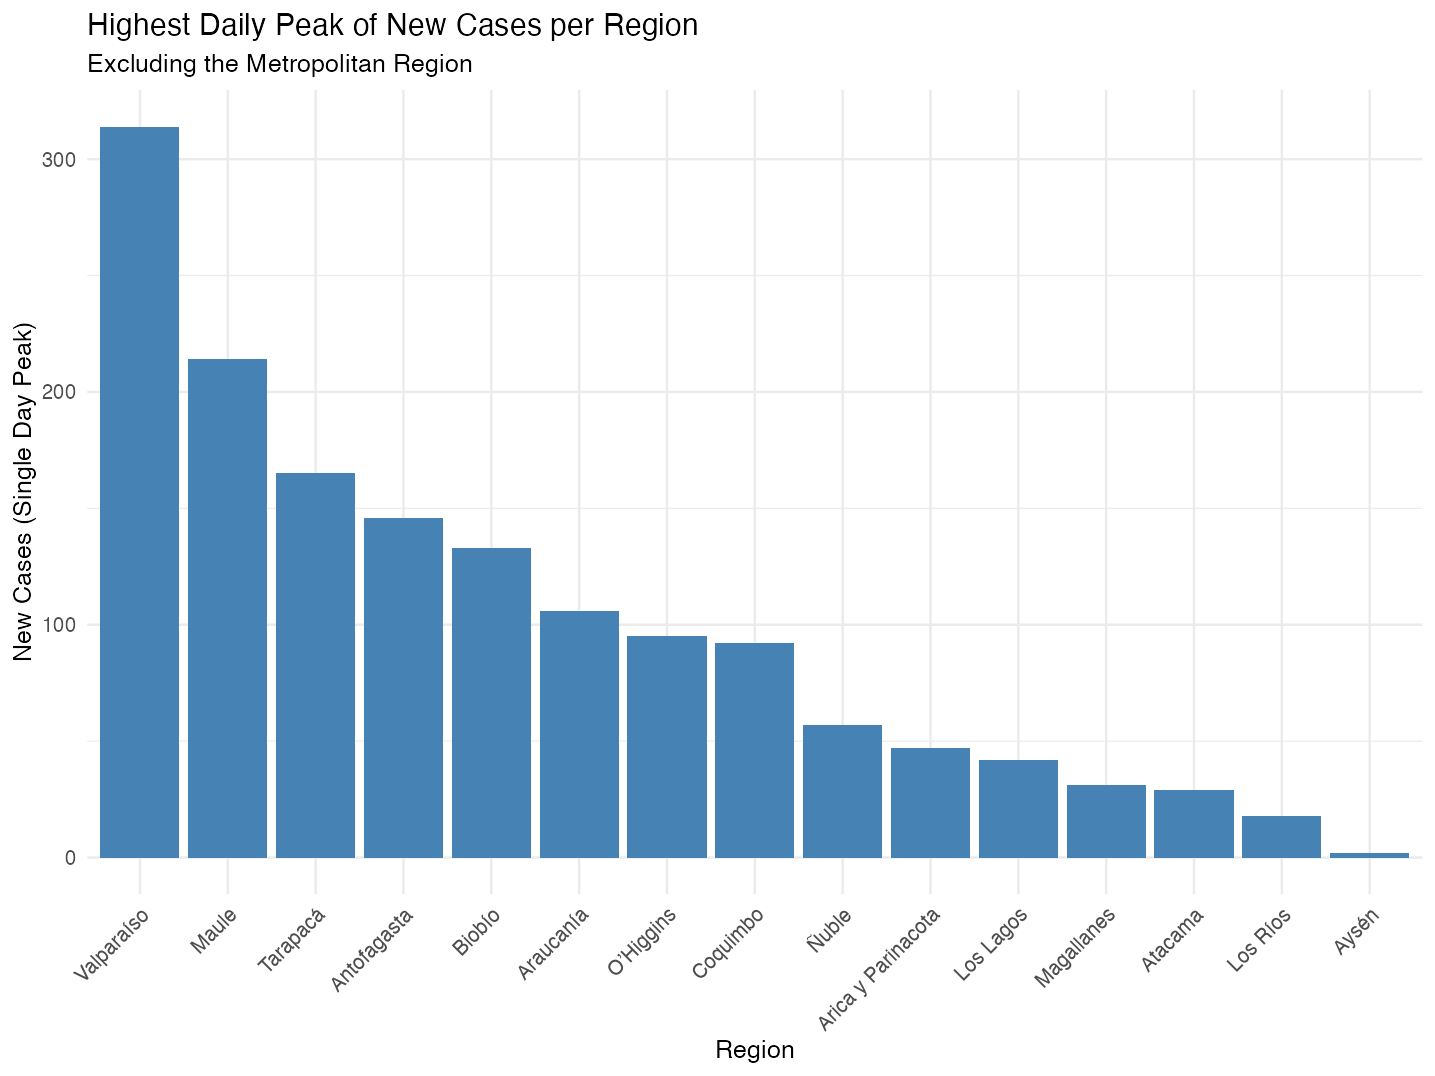

In [3]:
# Load required libraries
library(dplyr)
library(ggplot2)
library(lubridate)

# 1. Load the dataset
df <- read.csv("../data/covid-19-region.csv", stringsAsFactors = FALSE, check.names = FALSE)

# 2. Preprocess the data
df_filtered <- df %>%
  mutate(Fecha = ymd(Fecha),
         Casosnuevostotales = as.numeric(Casosnuevostotales)) %>%
  # Exclude the Metropolitan Region and any aggregate 'Total' rows
  filter(Region != "Metropolitana", Region != "Total", !is.na(Casosnuevostotales))

# 3. Find the highest peak
max_peak_row <- df_filtered[which.max(df_filtered$Casosnuevostotales), ]

# 4. Aggregate maximum peaks by region for the graph
regional_peaks <- df_filtered %>%
  group_by(Region) %>%
  summarise(Peak_Cases = max(Casosnuevostotales, na.rm = TRUE)) %>%
  arrange(desc(Peak_Cases))

# 5. Create the visualization
ggplot(regional_peaks, aes(x = reorder(Region, -Peak_Cases), y = Peak_Cases)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  theme_minimal() +
  labs(title = "Highest Daily Peak of New Cases per Region",
       subtitle = "Excluding the Metropolitan Region",
       x = "Region",
       y = "New Cases (Single Day Peak)") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# 6. Output the specific result to the console
cat("The region with the highest peak (excluding Metropolitana) is:", max_peak_row$Region, "\n")
cat("Date of peak:", as.character(max_peak_row$Fecha), "\n")
cat("Number of cases:", max_peak_row$Casosnuevostotales, "\n")